
# FD02 — Forest Loss Baseline Experiment

## Objective
Establish a simple, reproducible rule-based baseline for examining
historical tree-cover loss in relation to estimated tree canopy cover.

## Dataset
Hansen Global Forest Change v1.11 (2000–2023):
- treecover2000: estimated tree canopy cover percentage in 2000.
- lossyear: recorded year of tree-cover loss.

## Baseline rule
For an exploratory canopy threshold of 30%:
- Canopy-qualified pixel: treecover2000 >= 30
- Recorded-loss pixel: lossyear > 0
- Baseline flag: canopy-qualified AND recorded-loss pixel

## Research question
How does the number of recorded-loss pixels associated with areas
meeting different initial canopy-cover thresholds change when the
threshold is set to 10%, 30%, or 50%?

## Important limitation
This experiment analyzes historical labels from the same dataset.
It does not independently validate forest loss, predict future loss,
or prove that loss represents permanent deforestation.

In [3]:

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.enums import Resampling

BASE_DIR = "/content/forest_disturbance"
DATA_DIR = os.path.join(BASE_DIR, "data")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Setup complete")
print("Data directory:", DATA_DIR)
print("Results directory:", RESULTS_DIR)

Setup complete
Data directory: /content/forest_disturbance/data
Results directory: /content/forest_disturbance/results


In [4]:

import os
import glob

# Search common locations used in the FD01 experiment
search_roots = [
    "/content/forest_disturbance",
    "/content",
]

treecover_matches = []
lossyear_matches = []

for root in search_roots:
    if not os.path.exists(root):
        continue

    treecover_matches.extend(
        glob.glob(
            os.path.join(root, "**", "*treecover2000_20N_080E.tif"),
            recursive=True
        )
    )
    lossyear_matches.extend(
        glob.glob(
            os.path.join(root, "**", "*lossyear_20N_080E.tif"),
            recursive=True
        )
    )

# Remove duplicate paths
treecover_matches = sorted(set(treecover_matches))
lossyear_matches = sorted(set(lossyear_matches))

print("Tree-cover files found:")
for path in treecover_matches:
    print(" ", path)

print("\nLoss-year files found:")
for path in lossyear_matches:
    print(" ", path)

if treecover_matches and lossyear_matches:
    TREECOVER_PATH = treecover_matches[0]
    LOSSYEAR_PATH = lossyear_matches[0]

    print("\nRecovery successful!")
    print("TREECOVER_PATH =", TREECOVER_PATH)
    print("LOSSYEAR_PATH  =", LOSSYEAR_PATH)
else:
    print("\nOne or both files are missing.")
    print("Check whether the FD01 files still exist in the current Colab session.")

Tree-cover files found:

Loss-year files found:

One or both files are missing.
Check whether the FD01 files still exist in the current Colab session.


In [6]:

# Cell 4A — Reset imports and locate the raster files

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
from rasterio.enums import Resampling

BASE_DIR = "/content/forest_disturbance"
DATA_DIR = os.path.join(BASE_DIR, "data")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

def find_raster(pattern):
    matches = []
    for root in ["/content/forest_disturbance", "/content"]:
        if os.path.exists(root):
            matches.extend(
                glob.glob(os.path.join(root, "**", pattern), recursive=True)
            )
    return sorted(set(matches))

tree_files = find_raster("*treecover2000_20N_080E.tif")
loss_files = find_raster("*lossyear_20N_080E.tif")

print("rasterio version:", rasterio.__version__)
print("Tree-cover files found:", tree_files)
print("Loss-year files found:", loss_files)

rasterio version: 1.5.2
Tree-cover files found: []
Loss-year files found: []


In [7]:

# Cell 4B — Find or download the two Hansen raster layers

import requests

BASE_URL = (
    "https://storage.googleapis.com/"
    "earthenginepartners-hansen/GFC-2023-v1.11/"
)

file_specs = {
    "treecover2000": "Hansen_GFC-2023-v1.11_treecover2000_20N_080E.tif",
    "lossyear": "Hansen_GFC-2023-v1.11_lossyear_20N_080E.tif",
}

paths = {}

for key, filename in file_specs.items():
    matches = find_raster(filename)

    if matches:
        paths[key] = matches[0]
        print(f"Reusing {key}: {paths[key]}")
        continue

    destination = os.path.join(DATA_DIR, filename)
    url = BASE_URL + filename
    print(f"Downloading missing layer: {filename}")

    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()

    with open(destination, "wb") as f:
        for chunk in response.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)

    paths[key] = destination
    print(f"Saved: {destination}")

TREECOVER_PATH = paths["treecover2000"]
LOSSYEAR_PATH = paths["lossyear"]

print("\nBoth raster paths are ready.")

Saved: /content/forest_disturbance/data/Hansen_GFC-2023-v1.11_treecover2000_20N_080E.tif
Saved: /content/forest_disturbance/data/Hansen_GFC-2023-v1.11_lossyear_20N_080E.tif

Both raster paths are ready.


In [8]:

# Cell 4C — Check CRS, dimensions, transforms, and bounds

with rasterio.open(TREECOVER_PATH) as tc, \
     rasterio.open(LOSSYEAR_PATH) as ly:

    print("Tree-cover CRS:", tc.crs)
    print("Loss-year CRS:", ly.crs)
    print("Tree-cover dimensions:", tc.width, tc.height)
    print("Loss-year dimensions:", ly.width, ly.height)
    print("Transforms match:", tc.transform == ly.transform)
    print("Bounds match:", tc.bounds == ly.bounds)

    aligned = (
        tc.crs == ly.crs
        and tc.width == ly.width
        and tc.height == ly.height
        and tc.transform == ly.transform
        and tc.bounds == ly.bounds
    )

print("\nSpatial alignment:", "PASS" if aligned else "FAIL")

if not aligned:
    raise ValueError(
        "Raster grids differ. Stop here; do not compare pixels "
        "until the layers have been aligned correctly."
    )

Tree-cover CRS: EPSG:4326
Loss-year CRS: EPSG:4326
Tree-cover dimensions: 40000 40000
Loss-year dimensions: 40000 40000
Transforms match: True
Bounds match: True

Spatial alignment: PASS


In [9]:

# Cell 5 — Read both layers on their matching grids

SAMPLE_SIZE = 2000

with rasterio.open(TREECOVER_PATH) as src:
    treecover = src.read(
        1,
        out_shape=(SAMPLE_SIZE, SAMPLE_SIZE),
        resampling=Resampling.nearest
    ).astype(np.float32)

with rasterio.open(LOSSYEAR_PATH) as src:
    lossyear = src.read(
        1,
        out_shape=(SAMPLE_SIZE, SAMPLE_SIZE),
        resampling=Resampling.nearest
    ).astype(np.float32)

valid = (
    np.isfinite(treecover)
    & np.isfinite(lossyear)
    & (treecover >= 0) & (treecover <= 100)
    & (lossyear >= 0) & (lossyear <= 23)
)

print("Tree-cover shape:", treecover.shape)
print("Loss-year shape:", lossyear.shape)
print("Valid pixels:", int(valid.sum()))
print("Pixels excluded by range/finite checks:", int((~valid).sum()))

if valid.sum() == 0:
    raise ValueError("No valid pixels found.")

Tree-cover shape: (2000, 2000)
Loss-year shape: (2000, 2000)
Valid pixels: 4000000
Pixels excluded by range/finite checks: 0


In [10]:

# Cell 6 — Compare exploratory canopy thresholds

recorded_loss = valid & (lossyear > 0)
rows = []

for threshold in [10, 30, 50]:
    canopy = valid & (treecover >= threshold)
    flagged = canopy & recorded_loss

    rows.append({
        "canopy_threshold_percent": threshold,
        "valid_sample_pixels": int(valid.sum()),
        "canopy_qualified_pixels": int(canopy.sum()),
        "recorded_loss_pixels_passing_threshold": int(flagged.sum()),
        "all_recorded_loss_pixels": int(recorded_loss.sum()),
        "share_of_recorded_loss_pixels_passing_threshold_percent": (
            round(100 * flagged.sum() / recorded_loss.sum(), 2)
            if recorded_loss.sum() else np.nan
        )
    })

baseline_df = pd.DataFrame(rows)
display(baseline_df)

csv_path = os.path.join(RESULTS_DIR, "FD02_threshold_sensitivity.csv")
baseline_df.to_csv(csv_path, index=False)

print("Saved:", csv_path)

,canopy_threshold_percent,valid_sample_pixels,canopy_qualified_pixels,recorded_loss_pixels_passing_threshold,all_recorded_loss_pixels,share_of_recorded_loss_pixels_passing_threshold_percent
0,10,4000000,191744,9585,13611,70.42
1,30,4000000,144639,7940,13611,58.34
2,50,4000000,104142,5579,13611,40.99


Saved: /content/forest_disturbance/results/FD02_threshold_sensitivity.csv


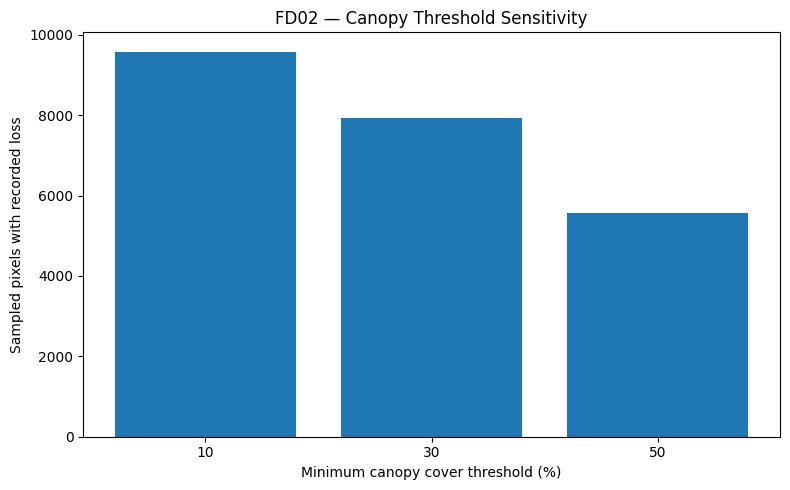

Saved: /content/forest_disturbance/results/FD02_threshold_sensitivity.png


In [11]:

# Cell 7 — Visualize threshold sensitivity

plt.figure(figsize=(8, 5))
plt.bar(
    baseline_df["canopy_threshold_percent"].astype(str),
    baseline_df["recorded_loss_pixels_passing_threshold"]
)
plt.xlabel("Minimum canopy cover threshold (%)")
plt.ylabel("Sampled pixels with recorded loss")
plt.title("FD02 — Canopy Threshold Sensitivity")
plt.tight_layout()

plot_path = os.path.join(RESULTS_DIR, "FD02_threshold_sensitivity.png")
plt.savefig(plot_path, dpi=160)
plt.show()

print("Saved:", plot_path)

In [12]:

# Cell 8 — Write a reproducible summary

summary_path = os.path.join(RESULTS_DIR, "FD02_summary.txt")

with open(summary_path, "w", encoding="utf-8") as f:
    f.write("FD02 — Forest Loss Baseline Experiment\n")
    f.write("=" * 42 + "\n\n")
    f.write(f"Sample shape: {treecover.shape}\n")
    f.write(f"Valid pixels: {int(valid.sum())}\n")
    f.write(f"Recorded-loss pixels: {int(recorded_loss.sum())}\n\n")
    f.write(baseline_df.to_string(index=False))
    f.write(
        "\n\nLimitations:\n"
        "- Descriptive rule-based analysis, not a trained model.\n"
        "- Loss-year data are not independent ground truth.\n"
        "- Results are sampled pixel counts, not area estimates.\n"
        "- No accuracy or predictive-performance claim is made.\n"
    )

print(open(summary_path, encoding="utf-8").read())
print("\nSaved:", summary_path)

FD02 — Forest Loss Baseline Experiment

Sample shape: (2000, 2000)
Valid pixels: 4000000
Recorded-loss pixels: 13611

 canopy_threshold_percent  valid_sample_pixels  canopy_qualified_pixels  recorded_loss_pixels_passing_threshold  all_recorded_loss_pixels  share_of_recorded_loss_pixels_passing_threshold_percent
                       10              4000000                   191744                                    9585                     13611                                                    70.42
                       30              4000000                   144639                                    7940                     13611                                                    58.34
                       50              4000000                   104142                                    5579                     13611                                                    40.99

Limitations:
- Descriptive rule-based analysis, not a trained model.
- Loss-year data are not indepen

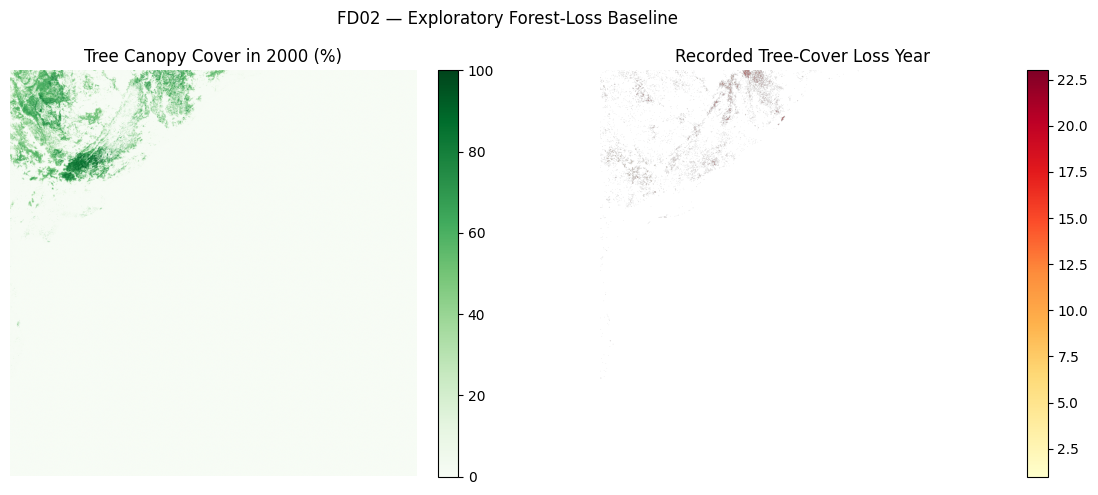

Saved: /content/forest_disturbance/results/FD02_baseline_visualization.png


In [13]:

# FD02 Cell 9 — Side-by-side baseline visualization

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cover_img = axes[0].imshow(
    np.where(valid, treecover, np.nan),
    vmin=0, vmax=100,
    cmap="Greens"
)
axes[0].set_title("Tree Canopy Cover in 2000 (%)")
axes[0].axis("off")
fig.colorbar(cover_img, ax=axes[0], fraction=0.046, pad=0.04)

loss_img = axes[1].imshow(
    np.where(valid & (lossyear > 0), lossyear, np.nan),
    vmin=1, vmax=23,
    cmap="YlOrRd"
)
axes[1].set_title("Recorded Tree-Cover Loss Year")
axes[1].axis("off")
fig.colorbar(loss_img, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle("FD02 — Exploratory Forest-Loss Baseline")
plt.tight_layout()

figure_path = os.path.join(RESULTS_DIR, "FD02_baseline_visualization.png")
plt.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", figure_path)

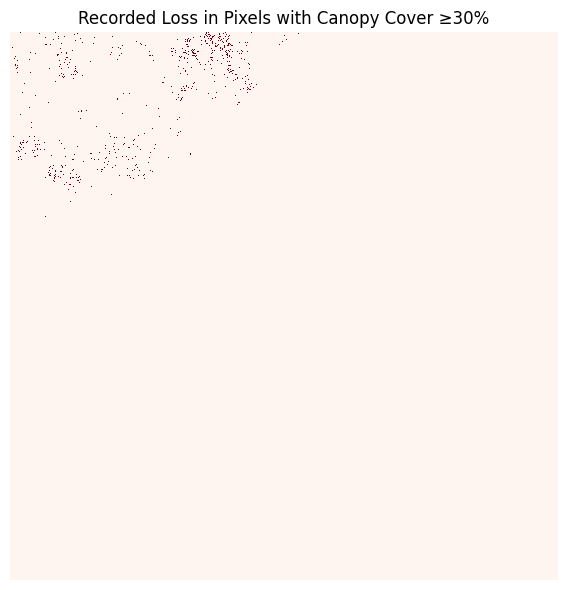

Baseline flagged pixels: 7940
This is a historical rule-based flag, not a validated prediction.
Saved: /content/forest_disturbance/results/FD02_30pct_baseline_map.png


In [14]:

# FD02 Cell 10 — Generate a simple binary baseline map

CANOPY_THRESHOLD = 30

baseline_map = (
    valid
    & (treecover >= CANOPY_THRESHOLD)
    & (lossyear > 0)
)

plt.figure(figsize=(7, 6))
plt.imshow(baseline_map, cmap="Reds", interpolation="nearest")
plt.title("Recorded Loss in Pixels with Canopy Cover ≥30%")
plt.axis("off")
plt.tight_layout()

map_path = os.path.join(RESULTS_DIR, "FD02_30pct_baseline_map.png")
plt.savefig(map_path, dpi=160, bbox_inches="tight")
plt.show()

print("Baseline flagged pixels:", int(baseline_map.sum()))
print("This is a historical rule-based flag, not a validated prediction.")
print("Saved:", map_path)

In [15]:

# FD02 Cell 11 — Final output verification

expected_files = [
    "FD02_threshold_sensitivity.csv",
    "FD02_threshold_sensitivity.png",
    "FD02_summary.txt",
    "FD02_baseline_visualization.png",
    "FD02_30pct_baseline_map.png",
]

print("FD02 output verification")
print("=" * 35)

for filename in expected_files:
    path = os.path.join(RESULTS_DIR, filename)
    print(f"{'OK' if os.path.exists(path) else 'MISSING'}: {filename}")

print("\nThreshold sensitivity results:")
display(pd.read_csv(os.path.join(RESULTS_DIR, "FD02_threshold_sensitivity.csv")))

FD02 output verification
OK: FD02_threshold_sensitivity.csv
OK: FD02_threshold_sensitivity.png
OK: FD02_summary.txt
OK: FD02_baseline_visualization.png
OK: FD02_30pct_baseline_map.png

Threshold sensitivity results:


,canopy_threshold_percent,valid_sample_pixels,canopy_qualified_pixels,recorded_loss_pixels_passing_threshold,all_recorded_loss_pixels,share_of_recorded_loss_pixels_passing_threshold_percent
0,10,4000000,191744,9585,13611,70.42
1,30,4000000,144639,7940,13611,58.34
2,50,4000000,104142,5579,13611,40.99


In [16]:

# FD02 Cell 12 — Save the conclusion

loss_total = int(recorded_loss.sum())
threshold_30 = baseline_df.loc[
    baseline_df["canopy_threshold_percent"] == 30
].iloc[0]

conclusion = f"""# FD02 — Forest Loss Baseline Conclusion

## Experiment status
The exploratory rule-based baseline ran successfully if all preceding
cells completed and the output verification checks passed.

## Data examined
- Sample dimensions: {treecover.shape}
- Valid sampled pixels: {int(valid.sum())}
- Pixels with a non-zero recorded loss year: {loss_total}
- Canopy threshold examined: 30%
- Pixels meeting the 30% canopy threshold and having a recorded loss year:
  {int(threshold_30['recorded_loss_pixels_passing_threshold'])}

## Findings
This experiment examines how counts of recorded-loss pixels change when
the minimum tree-canopy-cover threshold is varied across 10%, 30%, and 50%.
The measured results are recorded in FD02_threshold_sensitivity.csv.

## Interpretation and limitations
This is a descriptive, rule-based baseline using layers from the same
historical dataset. The recorded loss-year layer is not independent
ground truth. The experiment does not establish detection accuracy,
causality, permanent deforestation, or future predictive ability.
Counts refer to sampled pixels and are not area estimates.

## Next steps
Confirm raster alignment, document the study area and sampling approach,
and seek independent reference data before conducting a formal evaluation.
"""

conclusion_path = os.path.join(RESULTS_DIR, "FD02_conclusion.md")

with open(conclusion_path, "w", encoding="utf-8") as f:
    f.write(conclusion)

print(conclusion)
print("\nSaved:", conclusion_path)

# FD02 — Forest Loss Baseline Conclusion

## Experiment status
The exploratory rule-based baseline ran successfully if all preceding
cells completed and the output verification checks passed.

## Data examined
- Sample dimensions: (2000, 2000)
- Valid sampled pixels: 4000000
- Pixels with a non-zero recorded loss year: 13611
- Canopy threshold examined: 30%
- Pixels meeting the 30% canopy threshold and having a recorded loss year:
  7940

## Findings
This experiment examines how counts of recorded-loss pixels change when
the minimum tree-canopy-cover threshold is varied across 10%, 30%, and 50%.
The measured results are recorded in FD02_threshold_sensitivity.csv.

## Interpretation and limitations
This is a descriptive, rule-based baseline using layers from the same
historical dataset. The recorded loss-year layer is not independent
ground truth. The experiment does not establish detection accuracy,
causality, permanent deforestation, or future predictive ability.
Counts refer to sampl